## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 101**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 0$  
$\lambda_{bin} = 1$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools


delta = 1 
shape = (15,15)
model_name = 'ClassicBin'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'ClassicBin Model'

th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name) 

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.4202 ± 0.0008
val_loss: 0.4319 ± 0.0023


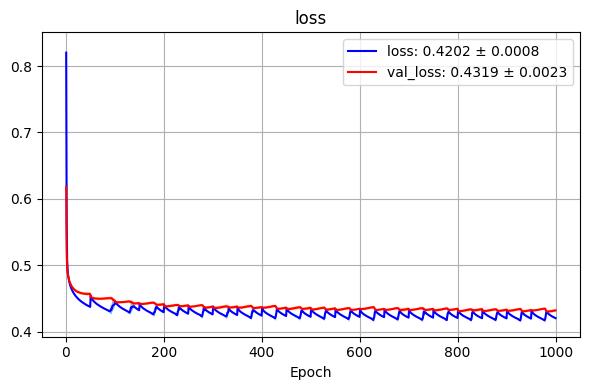

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8573 ± 0.0005
Accuracy_fin: 0.8093 ± 0.0008
Recall_init: 0.5836 ± 0.0034
Recall_fin: 0.1754 ± 0.0028
Specificity_init: 0.9362 ± 0.0009
Specificity_fin: 0.9881 ± 0.0002
Precision_init: 0.7253 ± 0.0020
Precision_fin: 0.8062 ± 0.0024
F1Score_init: 0.6468 ± 0.0017
F1Score_fin: 0.2881 ± 0.0039


--- Results Initial States (15 seeds) ---
Density (true): 22.39% ± 9.39%
Density (pred): 19.64% ± 7.77%
Error/seed:     2.75% ± 0.11%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 0.90% ± 0.05%
HUC% (0.4, 0.6): 1.87% ± 0.11%
HUC% (0.35, 0.65): 3.04% ± 0.16%
Fuzziness Index: 0.2077 ± 0.1160
MSE (prob):0.1097 ± 0.0666
MSE (bin):0.1427 ± 0.0876
MSE (all-zero): 0.2239 ± 0.0939
Wasserstein (EMD): 1.5123 ± 0.0042


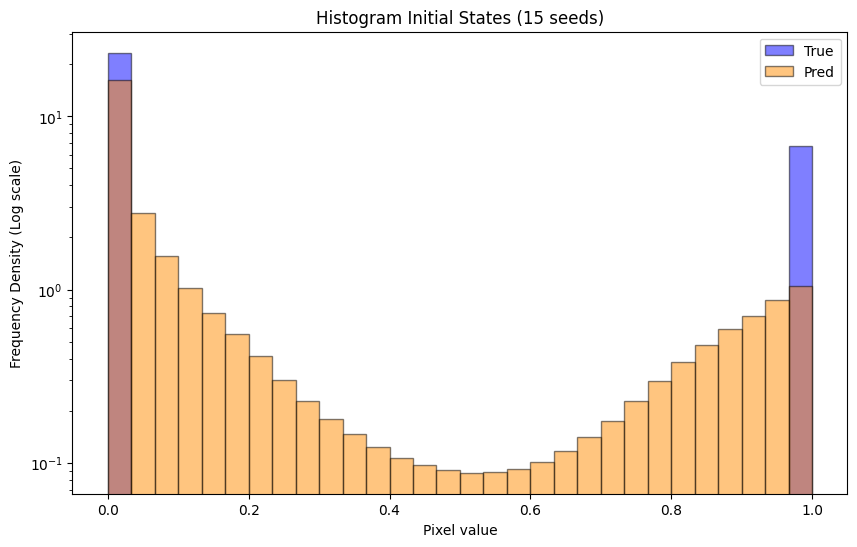

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 22.00% ± 9.81%
Density (pred): 5.40% ± 2.08%
Error/seed:     16.60% ± 0.08%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 1.17% ± 0.02%
HUC% (0.4, 0.6): 2.35% ± 0.03%
HUC% (0.35, 0.65): 3.53% ± 0.05%
Fuzziness Index: 0.0876 ± 0.0402
MSE (prob):0.1659 ± 0.0886
MSE (bin):0.1907 ± 0.1006
MSE (all-zero): 0.2200 ± 0.0981
Wasserstein (EMD): 2.7478 ± 0.0125


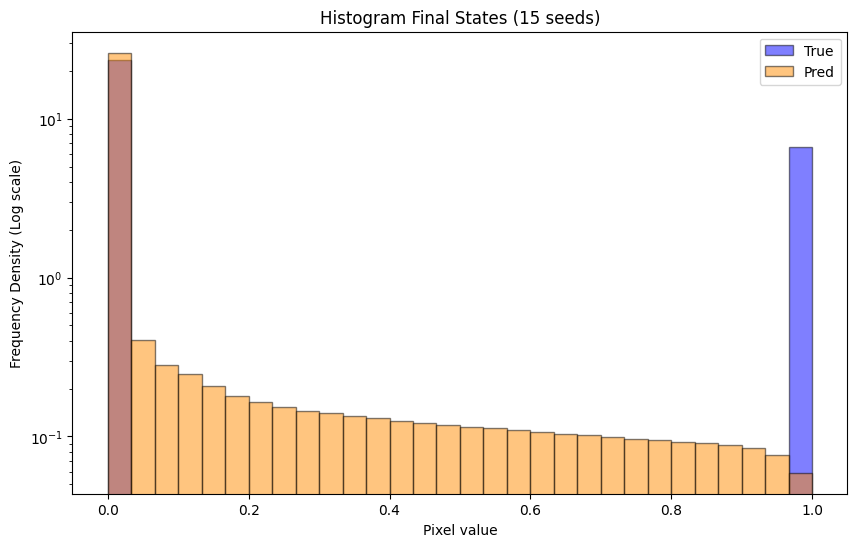

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

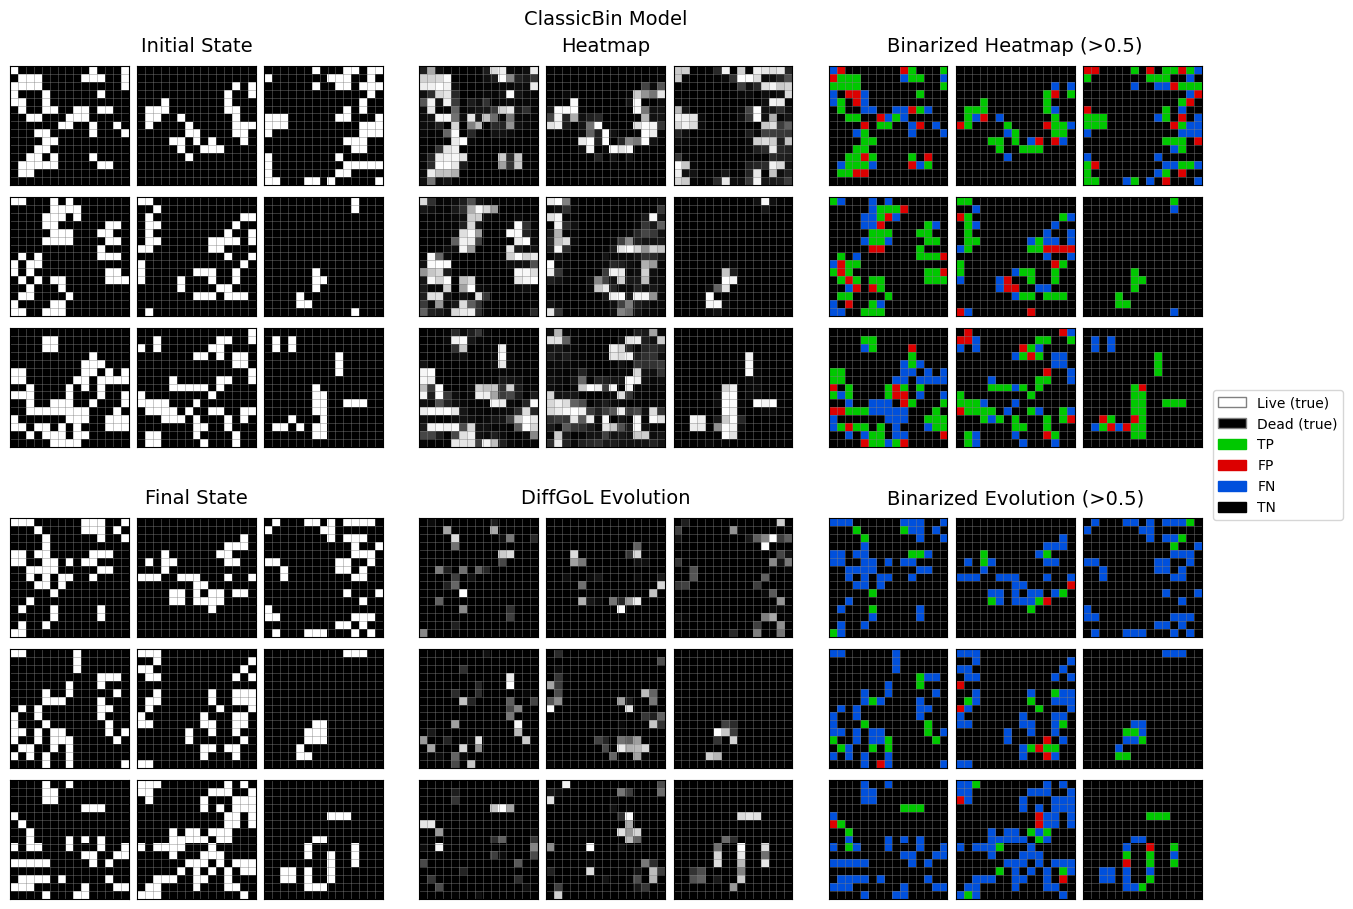

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)